# Class 2: Correlation Testing

In this class we will review how to quantify correlations between variables and test for their significance, and determine whether different samples are drawn from the same underlying distributions.  After these activities you should be able to ...

- test for the degree of correlation between 2 variables, and its significance
- implement correlation as a hypothesis test, and understand the significance of the resulting $p$-value
- test if two samples are drawn from the same parent distribution

## Correlation versus independence

Two variables are **correlated** if they share a statistical dependence / relationship.  A nice trick for generating correlated variables is:

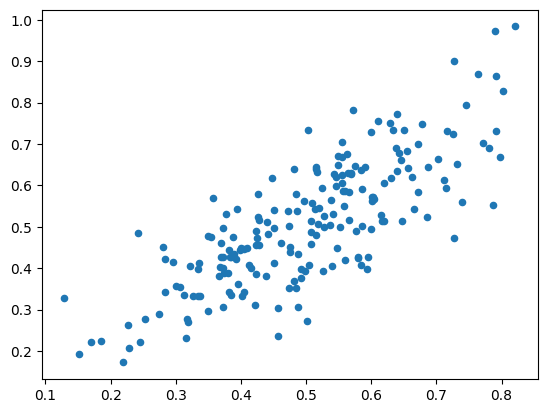

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

n = 200 # number of data points
r = 0.8 # correlation coefficient, between -1 and +1 (see below)
mux,sigx = 0.5,0.15 # mean and standard deviation of x
muy,sigy = 0.5,0.15 # mean and standard deviation of y

x = sigx*np.random.normal(size=n) # draw x from a Gaussian distribution with mean=0 and sig=sigx
y = sigy*np.random.normal(size=n) # draw y from a Gaussian distribution with mean=0 and sig=sigy
y1 = x*r + y*np.sqrt(1-r**2) # generate a new variable which is correlated with x with correlation coefficient r
x = x + mux # shift x to mean=mux
y = y1 + muy # shift y to mean=muy

plt.scatter(x,y,marker='o',s=20)

## Correlation coefficient

The **correlation coefficient** describes the **strength of the correlation** between two variables $(x,y)$.

If the variables have means $(\mu_x, \mu_y)$ and standard deviations $(\sigma_x, \sigma_y)$, then the definition of the correlation coefficient is:

$\rho = \frac{\langle (x - \mu_x) (y - \mu_y) \rangle}{\sigma_x \sigma_y} = \frac{\langle x y \rangle - \mu_x \, \mu_y}{\sigma_x \, \sigma_y}$

where

$\langle x y \rangle = \int_{-\infty}^\infty \int_{-\infty}^\infty x \, y \, P(x,y) \, dx \, dy$

Note: we'll use $\rho$ to mean the underlying **theoretical** correlation, and $r$ as the **value estimated from the data**.

For **no correlation**, $P(x,y)$ is separable into $f(x) \, g(y)$ hence $\langle x y \rangle = \langle x \rangle \langle y \rangle = \mu_x \mu_y$ and $\rho = 0$.

For **complete correlation**, $y = C x$ and $\rho = +1$.

For **complete anti-correlation**, $y = - C x$ and $\rho = -1$.

The possible range is $-1 \le \rho \le +1$.

## Correlation testing

Let's consider an example $(x,y)$ dataset and test whether the variables are correlated.  This may involve both **estimating the correlation coefficient** and **determining the likelihood of obtaining this correlation coefficient if the underlying data are uncorrelated** (i.e., testing whether the correlation has resulted by random chance).

First let's read in an example dataset:

Text(0, 0.5, '$y$')

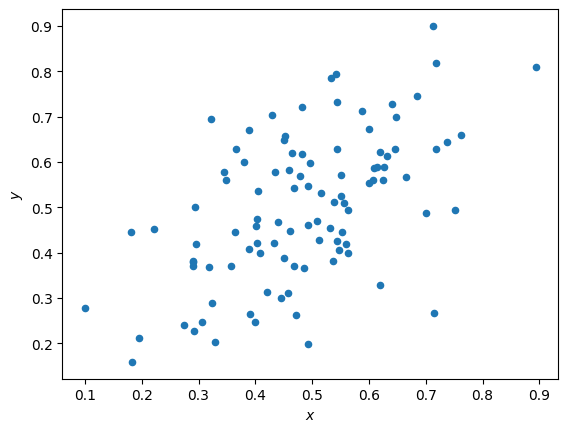

In [23]:
# Read in the file correlation_example.dat and make a scatter plot
# You will need to change the file path to the location where you've saved the data
data = np.loadtxt('../datasets/correlation_example.dat')
x,y = data[:,0],data[:,1]
n = len(x)
plt.scatter(x,y,marker='o',s=20)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

There seems to be a correlation by eye, but we need to test this quantitatively.

## Pearson product-moment correlation coefficient

We can estimate the correlation coefficient of data samples $(x_i, y_i)$ using the **Pearson product-moment formula**:

$r = \frac{\sum_i (x_i - \overline{x})(y_i - \overline{y})}{\sqrt{\sum_i (x_i - \overline{x})^2 \sum_i (y_i - \overline{y})^2}} = \frac{\sum_i x_i y_i - N \overline{x} \overline{y}}{(N-1) \sqrt{{\rm Var}(x) {\rm Var}(y)}}$

$r$ is an estimate of $\rho$ with possible range $-1 \le r \le +1$.

If we additionally suppose that $(x,y)$ are drawn from a **bivariate Gaussian distribution** (which often works pretty well), the expression for the **uncertainty** in the measured value if $r$ is:

$\sigma(r) = \sqrt{\frac{1-r^2}{N-2}}$

## Significance of a measured correlation

We can express the significance of a cross-correlation by testing the null hypothesis: **there is no correlation between the variables**.  This is done by computing a test statistic

$t = r \sqrt{\frac{N-2}{1-r^2}}$

and comparing it to the **Student's $t$ probability distribution** with number of degrees of freedom $\nu = N-2$.  The scipy stats package runs all these tests.

Here is how to compute these values for our test dataset:

In [24]:
from scipy import stats
r,p = stats.pearsonr(x,y) # evaluate Pearson correlation coefficient r and p-value for non-correlation
print('Correlation coefficient r =',r)
print('Error in r =',np.sqrt((1.-r**2)/float(n-2)))
print('p-value for non-correlation =',p)

Correlation coefficient r = 0.548341521611091
Error in r = 0.08447446031603906
p-value for non-correlation = 3.5136244603122277e-09


We can also break down this underlying calculation of the probability, for clarity:

In [4]:
t = r*np.sqrt(float(n-2)/(1-r**2)) # compute t-statistic
nu = n-2 # number of degrees of freedom
p = stats.t.sf(t,nu) # probability of t-distribution having this value or larger
p *= 2. # convert to 2-tailed test
print('t statistic =',t)
print('degrees of freedom nu =',nu)
print('p-value for non-correlation =',p) # should agree with value in the previous cell

t statistic = 6.491210711019814
degrees of freedom nu = 98
p-value for non-correlation = 3.5136244603122252e-09


## Activity

In this Activity we will check who discovered the expansion of the Universe!  Read in Hubble and Lemaitre's distance-velocity datasets.  For the two datasets, determine:

- the Pearson correlation coefficient
- its error
- its statistical significance

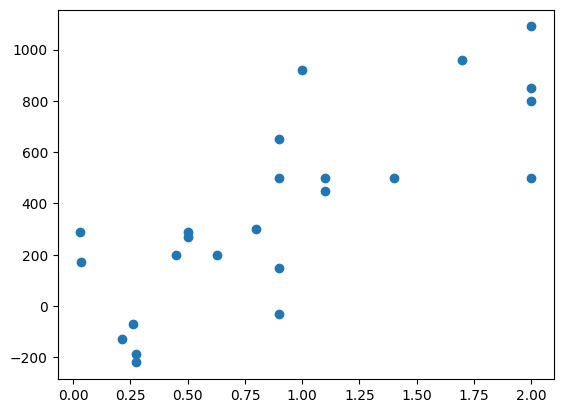

In [13]:
hubble = np.loadtxt('../datasets/hubble.dat')
plt.scatter(hubble[:, 0], hubble[:, 1])

In [14]:
r,p = stats.pearsonr(hubble[:, 0],hubble[:, 1]) # evaluate Pearson correlation coefficient r and p-value for non-correlation
n = hubble.shape[0]
print('Correlation coefficient r =',r)
print('Error in r =',np.sqrt((1.-r**2)/float(n-2)))
print('p-value for non-correlation =',p)

Correlation coefficient r = 0.7894101445353756
Error in r = 0.13087669834005064
p-value for non-correlation = 4.526254162836532e-06


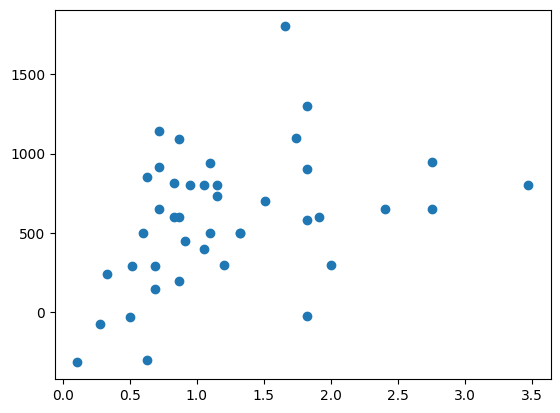

In [15]:
Lemaitre = np.loadtxt('../datasets/lemaitre.dat')
plt.scatter(Lemaitre[:, 0], Lemaitre[:, 1])

In [16]:
r,p = stats.pearsonr(Lemaitre[:, 0],Lemaitre[:, 1]) # evaluate Pearson correlation coefficient r and p-value for non-correlation
n = Lemaitre.shape[0]
print('Correlation coefficient r =',r)
print('Error in r =',np.sqrt((1.-r**2)/float(n-2)))
print('p-value for non-correlation =',p)

Correlation coefficient r = 0.3805931582211174
Error in r = 0.1462146408465373
p-value for non-correlation = 0.01290224808381018


## Meaning of the $p$-value

It is worth clarifying the meaning of the $p$-value resulting from calculations such as this.  Suppose that the significance of a (non-)correlation is $p = 0.01$.  This means:

- **there is a 1% chance of obtaining a set of measurements at least this correlated, if the underlying data is uncorrelated**

This does **not** mean:

- the probability that the points are uncorrelated is 1%
- the probability that the points are correlated is 99%
- if we claim a correlation, there is a 1% chance that we would be mistaken

**Frequentist statistics cannot assess the probability that the model itself is correct**.

## Spearman rank correlation coefficient

If we do not want to assume that $(x,y)$ are drawn from a bivariate Gaussian, we can use a non-parametric correlation test.  This can be done by evaluating the **Spearman rank correlation coefficient**.

This works as follows: let $(X_i, Y_i)$ be the rank of $(x_i, y_i)$ in the overall order, such that $1 \le X_i \le N$ and $1 \le Y_i \le N$.  Now compute

$r_s = 1 - 6 \frac{\sum_i (X_i - Y_i)^2}{N^3 - N}$

and the associated $p$-value as before.  This can be done as follows:

In [5]:
rho,p = stats.spearmanr(x,y) # evaluate Spearman rank correlation coefficient and p-value for non-correlation
print('Spearman correlation coefficient rho =',rho)
print('p-value for non-correlation =',p)

Spearman correlation coefficient rho = 0.5145394539453945
p-value for non-correlation = 4.34268433945076e-08


## Bayesian correlation coefficient

In the examples above, we have been determining **what is the probability of measuring a particular value of $r$ if there is no correlation?**.  Mathematically, that can be written as $P(r|\rho=0)$.

Bayesian statistics allow us to invert the problem and determine the **posterior probability distribution of the underlying correlation coefficient $\rho$ for a given value of $r$**, $P(\rho|r)$.

Assuming that $(x,y)$ data are drawn from a bivariate Gaussian distribution, there is an analytic relation for this:

$P(\rho|r) \propto \frac{(1-\rho^2)^{(N-1)/2}}{(1-\rho r)^{N-3/2}} \left( 1 + \frac{1}{N - 1/2} \frac{1+\rho r}{8} + ... \right)$

Here's how this may be evaluated for the example above:

Text(0, 0.5, '$P_{\\rm posterior}(\\rho)$')

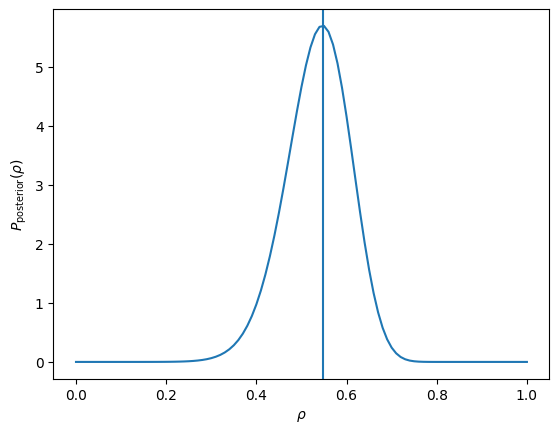

In [25]:
# Build the posterior probability distribution for the correlation coefficient rho
# Range of values of rho
xmin,xmax,nx = 0.,1.,101
x = np.linspace(xmin,xmax,nx)
dx = (xmax-xmin)/nx
# Evaluate the different terms inside the above equation for P(rho|r), separated for clarity
t1 = (1.-x**2)**(0.5*(n-1))
t2 = (1.-x*r)**(n-1.5)
t3 = (1. + (1./(n-0.5))*((1.+r*x)/8.))
# Combine the terms to determine P(rho|r)
y = (t1/t2)*t3
# Normalise the probability distribution such that \int P(rho) drho = 1
y /= np.sum(y)*dx
# Plot the posterior probability distribution for rho
plt.plot(x,y)
plt.axvline(r)
plt.xlabel(r'$\rho$')
plt.ylabel(r'$P_{\rm posterior}(\rho)$')

## Activity

Let's return to Hubble and Lemaitre's datasets.  For these datasets, determine:

- The Spearman rank correlation coefficient
- Its statistical significance
- The Bayesian posterior probability distribution of the correlation coefficient

In [19]:
rho,p = stats.spearmanr(hubble[:, 0],hubble[:, 1]) # evaluate Spearman rank correlation coefficient and p-value for non-correlation
print('Spearman correlation coefficient rho =',rho)
print('p-value for non-correlation =',p)

Spearman correlation coefficient rho = 0.795621148826282
p-value for non-correlation = 3.359537510261909e-06


Text(0, 0.5, '$P_{\\rm posterior}(\\rho)$')

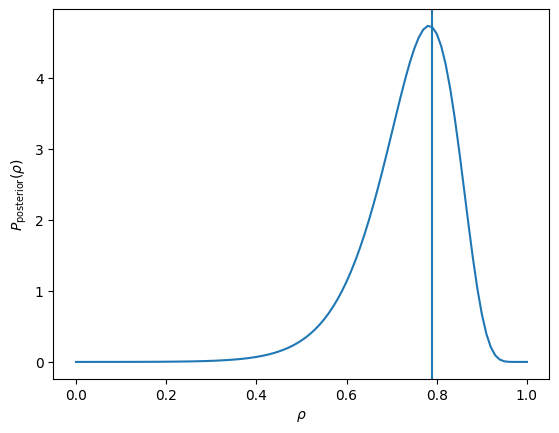

In [20]:
r,p = stats.pearsonr(hubble[:, 0],hubble[:, 1]) # evaluate Pearson correlation coefficient r and p-value for non-correlation
n = hubble.shape[0]
# Build the posterior probability distribution for the correlation coefficient rho
# Range of values of rho
xmin,xmax,nx = 0.,1.,101
x = np.linspace(xmin,xmax,nx)
dx = (xmax-xmin)/nx
# Evaluate the different terms inside the above equation for P(rho|r), separated for clarity
t1 = (1.-x**2)**(0.5*(n-1))
t2 = (1.-x*r)**(n-1.5)
t3 = (1. + (1./(n-0.5))*((1.+r*x)/8.))
# Combine the terms to determine P(rho|r)
y = (t1/t2)*t3
# Normalise the probability distribution such that \int P(rho) drho = 1
y /= np.sum(y)*dx
# Plot the posterior probability distribution for rho
plt.plot(x,y)
plt.axvline(r)
plt.xlabel(r'$\rho$')
plt.ylabel(r'$P_{\rm posterior}(\rho)$')

In [29]:
rho,p = stats.spearmanr(Lemaitre[:, 0],Lemaitre[:, 1]) # evaluate Spearman rank correlation coefficient and p-value for non-correlation
print('Spearman correlation coefficient rho =',rho)
print('p-value for non-correlation =',p)

Spearman correlation coefficient rho = 0.4170389074749948
p-value for non-correlation = 0.006003645513959774


Text(0, 0.5, '$P_{\\rm posterior}(\\rho)$')

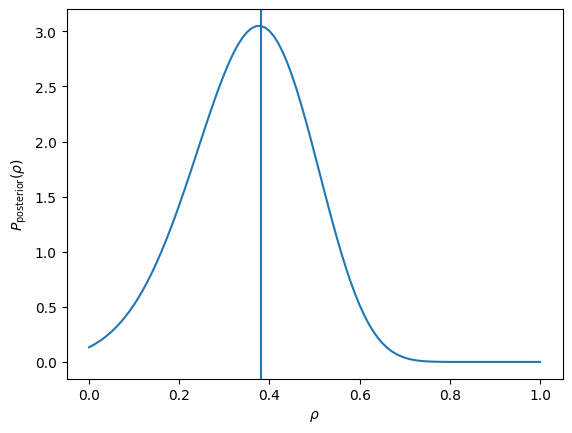

In [22]:
r,p = stats.pearsonr(Lemaitre[:, 0],Lemaitre[:, 1]) # evaluate Pearson correlation coefficient r and p-value for non-correlation
n = Lemaitre.shape[0]
# Build the posterior probability distribution for the correlation coefficient rho
# Range of values of rho
xmin,xmax,nx = 0.,1.,101
x = np.linspace(xmin,xmax,nx)
dx = (xmax-xmin)/nx
# Evaluate the different terms inside the above equation for P(rho|r), separated for clarity
t1 = (1.-x**2)**(0.5*(n-1))
t2 = (1.-x*r)**(n-1.5)
t3 = (1. + (1./(n-0.5))*((1.+r*x)/8.))
# Combine the terms to determine P(rho|r)
y = (t1/t2)*t3
# Normalise the probability distribution such that \int P(rho) drho = 1
y /= np.sum(y)*dx
# Plot the posterior probability distribution for rho
plt.plot(x,y)
plt.axvline(r)
plt.xlabel(r'$\rho$')
plt.ylabel(r'$P_{\rm posterior}(\rho)$')

## Are two samples drawn from the same distribution?

We now consider how to test whether two samples are drawn from the same parent distribution.  As a worked example, let's consider the following two datasets:

- N=100 points sampled from a Gaussian with mean=0 and sigma=1 (gaussian_sample1.dat)
- N=150 points sampled from a Gaussian with mean=0.2 and sigma=1 (gaussian_sample2.dat)

(array([ 1.,  0.,  2.,  1.,  1.,  2.,  0.,  1.,  2.,  3.,  4.,  3.,  4.,
         3.,  2.,  7.,  7.,  6.,  7.,  9.,  4.,  6.,  8.,  1.,  4., 10.,
         5.,  3.,  8.,  4.,  5.,  3.,  6.,  4.,  2.,  4.,  4.,  0.,  1.,
         0.]),
 array([-2. , -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1. ,
        -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,
         0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,  1.1,  1.2,
         1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ]),
 <BarContainer object of 40 artists>)

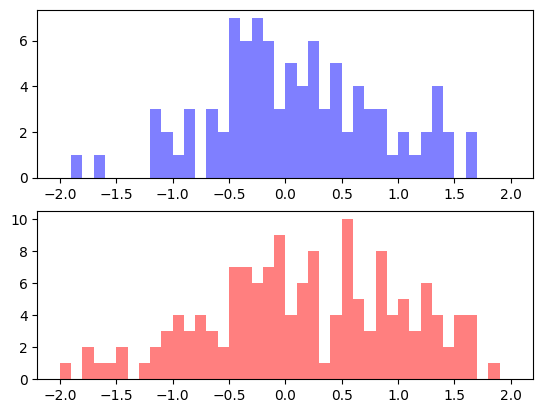

In [9]:
# Plot a histogram of two samples which are drawn from Gaussian distributions with slightly offset means
# You will need to change the file path to the location where you've saved the data
x = np.loadtxt('../datasets/gaussian_sample1.dat')
y = np.loadtxt('../datasets/gaussian_sample2.dat')
xmin,xmax,nx = -2.,2.,40
plt.subplot(211)
plt.hist(x,bins=nx,range=[xmin,xmax],histtype='bar',color='blue',alpha=0.5)
plt.subplot(212)
plt.hist(y,bins=nx,range=[xmin,xmax],histtype='bar',color='red',alpha=0.5)

## Do these distributions have the same mean?

We can test whether these distributions have the same mean by computing the $t$-statistic and comparing it with the Student's $t$ distribution:

In [10]:
# Evaluate the t-statistic which tests whether two samples have the same mean
# Evaluate the probability p of rejecting the hypothesis that the two samples have the same mean
t,p = stats.ttest_ind(x,y)
print('t statistic =',t)
print('Probability of rejecting hypothesis of same mean =',p)

t statistic = -1.6491481586932408
Probability of rejecting hypothesis of same mean = 0.10038336585739205


We conclude here that we cannot reject the hypothesis that the two distributions have the same mean.

## Kolmogorov-Smirnov (K-S) test

We can also test the hypothesis that these samples are drawn from the same parent distribution by evaluating the **Kolmogorov-Smirnov** (K-S) statistic.

This test considers the **maximum value of the absolute difference between the cumulative probability distributions of the 2 samples.**

We can run it in scipy as follows:

In [11]:
# Evaluate the KS statistic which tests whether two samples are drawn from the same parent distribution
# The KS statistic is the maximum value of the absolute difference between the cumulative probability distributions
# Evaluate the probability p of rejecting the hypothesis that the two samples are drawn from the same distribution
d,p = stats.ks_2samp(x,y)
print('K-S statistic d =',d)
print('Probability of rejecting hypothesis of same distribution =',p)

K-S statistic d = 0.13666666666666666
Probability of rejecting hypothesis of same distribution = 0.1995973223102136


## Activity

The provided datasets list estimated masses for neutron stars which **are** in double neutron star binaries (ns_masses1.dat), and are **not** in double neutron star binaries (ns_masses2.dat).

- Use the t-test to determine whether there is any significant difference in the means of the two samples
- Use the K-S test to determine whether these mass distributions are consistent

In [26]:
dns = np.loadtxt('../datasets/ns_masses1.dat')
ns = np.loadtxt('../datasets/ns_masses2.dat')

(array([0.69767442, 1.39534884, 0.55813953, 0.62790698, 0.06976744,
        0.13953488]),
 array([1.02      , 1.30666667, 1.59333333, 1.88      , 2.16666667,
        2.45333333, 2.74      ]),
 <BarContainer object of 6 artists>)

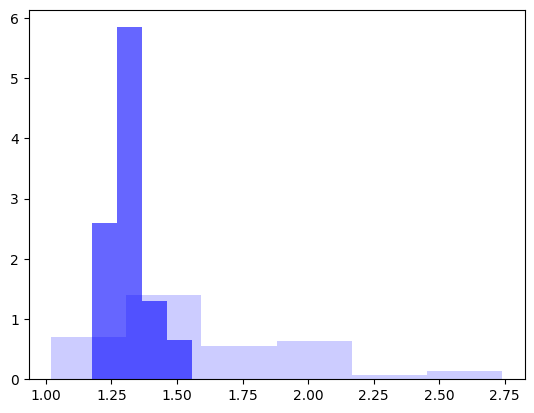

In [31]:
plt.hist(dns, density=True, bins='scott', alpha=0.6, color='blue')
plt.hist(ns, density=True, bins='scott', alpha=0.2, color='blue')

In [38]:
t,p = stats.ttest_ind(dns,ns)
print('t statistic =',t)
print('Probability of rejecting hypothesis of same mean =',1-p)

d,p = stats.ks_2samp(dns, ns)
print('\nK-S statistic d =',d)
print('Probability of rejecting hypothesis of same distribution =',1-p)

t statistic = -3.1063945137800437
Probability of rejecting hypothesis of same mean = 0.9971775552606518

K-S statistic d = 0.615
Probability of rejecting hypothesis of same distribution = 0.9999238745585863
